#  Обнаружение объектов

1. Рассмотрите простейшую архитектуру для решения задачи object detection и процесс настройки модели.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# Путь к архиву и папке для распаковки
zip_file_path = '/content/drive/MyDrive/animals.zip'
extract_folder = '/content/animals_extracted/'

# Распаковка архива
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"Архив распакован в {extract_folder}")

Архив распакован в /content/animals_extracted/


<p class="task" id="1"></p>

2\. Напишите функцию `parse_xml`, которая читает xml-файл с разметкой изображения из архива `animals.zip` и возвращает словарь, содержащий три ключа:
```
{
        "raw": # словарь с ключами xmin, ymin, xmax, ymax
        "scaled": # словарь с ключами xmin, ymin, xmax, ymax
        "obj_name": # строка
}
```
В этом словаре `row` - абсолютные значения координат вершин bounding box, а `scaled` - относительные (нормированные на ширину и высоту изображения). Примените функцию к файлу `cat.0.xml` и выведите результат на экран.

In [ ]:
import xml.etree.ElementTree as ET

def parse_xml(xml_path):
    # Чтение XML
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Извлечение имени объекта
    obj_name = root.find('.//object/name').text

    # Извлечение координат ограничивающей рамки
    xmin = int(root.find('.//bndbox/xmin').text)
    ymin = int(root.find('.//bndbox/ymin').text)
    xmax = int(root.find('.//bndbox/xmax').text)
    ymax = int(root.find('.//bndbox/ymax').text)

    # Получаем размеры изображения
    width = int(root.find('.//size/width').text)
    height = int(root.find('.//size/height').text)

    # Формируем raw-координаты
    raw_coords = {"xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax}

    # Нормализованные координаты
    scaled_coords = {
        "xmin": xmin / width,
        "ymin": ymin / height,
        "xmax": xmax / width,
        "ymax": ymax / height
    }

    # Возвращаем результат в нужном формате
    return {
        "raw": raw_coords,
        "scaled": scaled_coords,
        "obj_name": obj_name
    }

xml_path = '/content/animals_extracted/Asirra: cat vs dogs/cat.0.xml'
parsed_data = parse_xml(xml_path)
print(parsed_data)

{'raw': {'xmin': 126, 'ymin': 83, 'xmax': 354, 'ymax': 243}, 'scaled': {'xmin': 0.252, 'ymin': 0.22192513368983957, 'xmax': 0.708, 'ymax': 0.6497326203208557}, 'obj_name': 'cat'}


<p class="task" id="2"></p>

3\. Опишите датасет `AnimalDetectionDataset` на основе архива `animals.zip`. Реализуйте `__getitem__` таким образом, чтобы он возвращал три элемента: тензор с изображением, словарь с координатами bounding box и метку объекта. Предусмотрите возможность передавать извне при создании датасета набор преобразований для изображений, преобразование для метки объекта (для кодирования) и флаг, показывающий, нужно ли возвращать исходные или нормированные координаты bounding box.

In [ ]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import xml.etree.ElementTree as ET

class AnimalDetectionDataset(Dataset):
    def __init__(self, xml_folder, label_transform=None, return_scaled=True, transform=None, resize=(224, 224)):
        self.xml_folder = xml_folder
        self.label_transform = label_transform
        self.return_scaled = return_scaled
        self.transform = transform
        self.resize = resize  # Новый параметр для изменения размера
        self.annotations = [os.path.join(xml_folder, f) for f in os.listdir(xml_folder) if f.endswith('.xml')]

    def parse_xml(self, xml_file):
        tree = ET.parse(xml_file)
        root = tree.getroot()
        obj = root.find('object')
        bbox = obj.find('bndbox')
        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)

        # Извлечение размеров изображения из XML
        image_width = int(root.find('size').find('width').text)
        image_height = int(root.find('size').find('height').text)

        if self.return_scaled:
            # Нормализация bounding box
            xmin /= image_width
            ymin /= image_height
            xmax /= image_width
            ymax /= image_height

        obj_name = obj.find('name').text
        if self.label_transform:
            obj_name = self.label_transform(obj_name)

        return [xmin, ymin, xmax, ymax], obj_name, (image_width, image_height)

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        annotation = self.annotations[idx]
        bbox, label, (orig_width, orig_height) = self.parse_xml(annotation)
        image_path = annotation.replace('.xml', '.jpg')
        image = Image.open(image_path).convert("RGB")

        # Изменяем размер изображения
        target_width, target_height = self.resize
        image = image.resize((target_width, target_height))

        if not self.return_scaled:
            # Пересчет координат bounding box для изменения размера изображения
            scale_x = target_width / orig_width
            scale_y = target_height / orig_height
            xmin, ymin, xmax, ymax = bbox
            xmin *= scale_x
            ymin *= scale_y
            xmax *= scale_x
            ymax *= scale_y
            bbox = [xmin, ymin, xmax, ymax]

        if self.transform:
            image = self.transform(image)

        label = int(label)
        return image, torch.tensor(bbox, dtype=torch.float32), label

# Преобразование метки класса в число
def label_transform(label):
    label_dict = {"cat": 0, "dog": 1}  # Преобразование меток в числа
    return label_dict.get(label, -1)  # Возвращаем -1, если метка неизвестна

<p class="task" id="3"></p>

4\. Создайте объект класса `AnimalDetectionDataset` без применения преобразований и со значением `return_scaled=False`. Напишите функцию `show_image_with_bounding_box` для визуализации изображения с добавлением на него bounding box и подписи объекта. Продемонстрируйте работу функцию на изображении собаки и кошки.

In [ ]:
# Путь к папке с аннотациями (измените на реальный путь)
xml_folder = '/content/animals_extracted/Asirra: cat vs dogs'

# Создаем датасет
dataset = AnimalDetectionDataset(xml_folder, label_transform=label_transform, return_scaled=False)

# Получаем первый элемент
image, bbox, class_label = dataset[0]

# Печатаем результаты
print("Image tensor:", image.size)  # Размер изображения
print("Bounding box (raw):", bbox)  # Координаты bounding box
print("Class label:", class_label)  # Метка класса

Image tensor: (224, 224)
Bounding box (raw): tensor([ 13.0420,   7.0636, 213.8156, 215.8346])
Class label: 1


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.transforms import ToPILImage

def show_image_with_bounding_box(image, bbox, label):
    """
    Визуализирует изображение с bounding box и подписью объекта.

    Args:
        image (PIL.Image or Tensor): Изображение.
        bbox (dict): Bounding box с ключами xmin, ymin, xmax, ymax.
        label (str): Название объекта (например, 'cat' или 'dog').
    """
    # Если изображение в формате Tensor, преобразуем его в PIL.Image
    if isinstance(image, torch.Tensor):
        image = ToPILImage()(image)

    # Визуализация изображения
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    # Добавление bounding box
    rect = patches.Rectangle(
        (bbox['xmin'], bbox['ymin']),  # Верхний левый угол
        bbox['xmax'] - bbox['xmin'],  # Ширина
        bbox['ymax'] - bbox['ymin'],  # Высота
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)

    # Добавление подписи объекта
    ax.text(
        bbox['xmin'], bbox['ymin'] - 10, label,
        color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.5)
    )

    plt.axis('off')
    plt.show()

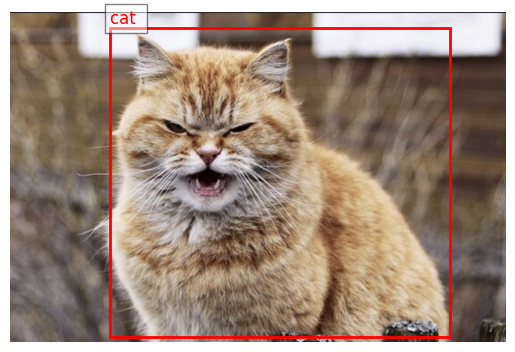

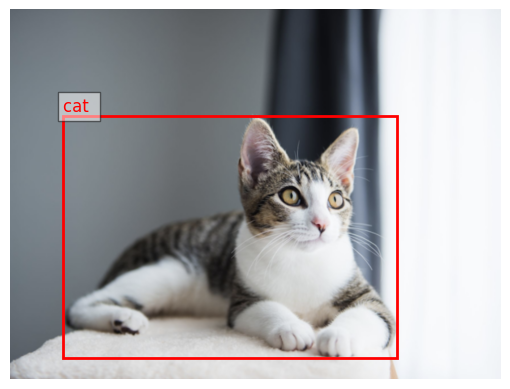

In [ ]:
# Визуализация изображения кошки
cat_image, cat_bbox, cat_label = dataset[0]  # Предполагаем, что 0 — индекс изображения кошки
show_image_with_bounding_box(cat_image, cat_bbox, cat_label)

# Визуализация изображения собаки
dog_image, dog_bbox, dog_label = dataset[1]  # Предполагаем, что 1 — индекс изображения собаки
show_image_with_bounding_box(dog_image, dog_bbox, dog_label)

<p class="task" id="4"></p>

5\. Напишите модель для решения задачи выделения объектов. Реализуйте двухголовую сеть, одна голова которой предсказывает метку объекта (задача классификации), а вторая голова предсказывает 4 координаты вершин bounding box (задача регрессии). В качестве backbone используйте модель resnet50 из пакета `torchvision`.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class ObjectDetectionResNet50(nn.Module):
    def __init__(self, num_classes=2):  # Количество классов для классификации
        super(ObjectDetectionResNet50, self).__init__()

        # Загружаем ResNet50, исключая классификационные слои
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(self.backbone.children())[:-2])  # Убираем avgpool и fc

        # Голова для предсказания координат (bbox)
        self.regression_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 4)  # 4 координаты (xmin, ymin, xmax, ymax)
        )

        # Голова для классификации (кот или собака)
        self.classification_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes)  # Количество классов
        )

    def forward(self, x):
        # Извлекаем признаки с помощью backbone
        features = self.backbone(x)

        # Получаем предсказания
        bbox = self.regression_head(features)
        class_logits = self.classification_head(features)

        return bbox, class_logits

<p class="task" id="5"></p>

6\. Разбейте набор данных на обучающее и валидационное множество. Обучите модель, описанную в задаче 4. При создании датасета не забудьте указать преобразования, соответствующие модели ResNet.

Используйте сумму MSELoss (для расчета ошибки на задаче регрессии) и CrossEntropyLoss (для расчета ошибки на задачи классификации) для настройки весов модели. Для ускорения процесса обучения слои backbone можно заморозить. Во время обучения выводите на экран значения функции потерь на обучающем и валидационном множестве. Используя обученную модель, получите предсказания для изображения кошки и собаки и отрисуйте их. Выполните процедуру, обратную нормализации, чтобы корректно отобразить фотографии.

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Изменяем размер изображения до 224x224 (необходимо для ResNet)
    transforms.ToTensor(),  # Преобразуем изображение в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Нормализация для ResNet
])

In [ ]:
from torch.utils.data import random_split

# Создаем датасет
dataset = AnimalDetectionDataset(xml_folder, label_transform=label_transform, return_scaled=False, transform=transform)

# Разделяем датасет на обучающий (90%) и тестовый (10%)
train_size = int(0.9 * len(dataset))  # 90% для обучения
test_size = len(dataset) - train_size  # 10% для теста

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Пример вывода размера тренировочного и тестового датасетов
print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 990
Test dataset size: 110


In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
def compute_iou(pred_bbox, true_bbox):
    # Преобразуем координаты из нормализованных в абсолютные, если нужно
    x1_pred, y1_pred, x2_pred, y2_pred = pred_bbox
    x1_true, y1_true, x2_true, y2_true = true_bbox

    # Находим координаты пересечения
    x1_inter = max(x1_pred, x1_true)
    y1_inter = max(y1_pred, y1_true)
    x2_inter = min(x2_pred, x2_true)
    y2_inter = min(y2_pred, y2_true)

    # Вычисляем площадь пересечения
    inter_area = max(0, x2_inter - x1_inter) * max(0, y2_inter - y1_inter)

    # Площадь предсказанного и истинного прямоугольников
    pred_area = (x2_pred - x1_pred) * (y2_pred - y1_pred)
    true_area = (x2_true - x1_true) * (y2_true - y1_true)

    # Вычисляем IoU
    iou = inter_area / (pred_area + true_area - inter_area)
    return iou

In [ ]:
import torch.optim as optim
from tqdm import tqdm

# Функция для расчета общей потери
def calculate_loss(pred_bboxes, true_bboxes, pred_classes, true_classes):
    regression_loss = nn.MSELoss()(pred_bboxes, true_bboxes)  # Потеря для регрессии
    classification_loss = nn.CrossEntropyLoss()(pred_classes, true_classes)  # Потеря для классификации
    return regression_loss + classification_loss  # Общая потеря

# Функция для вычисления точности классификации
def calculate_class_accuracy(pred_classes, true_classes):
    _, predicted_labels = torch.max(pred_classes, dim=1)
    correct_predictions = (predicted_labels == true_classes).sum().item()
    accuracy = correct_predictions / true_classes.size(0)
    return accuracy

# Функция для вычисления точности на основе IoU (для координат)
def calculate_bbox_accuracy(pred_bboxes, true_bboxes, iou_threshold=0.5):
    batch_size = pred_bboxes.size(0)
    correct_predictions = 0

    for i in range(batch_size):
        iou = compute_iou(pred_bboxes[i], true_bboxes[i])
        if iou > iou_threshold:
            correct_predictions += 1

    accuracy = correct_predictions / batch_size
    return accuracy

# Инициализация модели, оптимизатора и критерия потерь
model = ObjectDetectionResNet50(num_classes=2)  # Обновленная модель
optimizer = optim.Adam(model.parameters(), lr=1e-4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Количество эпох
num_epochs = 20

# Цикл обучения и тестирования
for epoch in range(num_epochs):
    model.train()  # Переводим модель в режим обучения
    running_loss = 0.0
    running_bbox_accuracy = 0.0  # Для точности координат
    running_class_accuracy = 0.0  # Для точности классификации

    # Обучение
    for images, bboxes, classes in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", ncols=100):
        images = images.to(device)
        bboxes = bboxes.to(device)
        classes = classes.to(device)

        optimizer.zero_grad()  # Обнуляем градиенты

        # Прогоняем через модель
        predicted_bboxes, predicted_classes = model(images)

        # Рассчитываем потери
        loss = calculate_loss(predicted_bboxes, bboxes, predicted_classes, classes)

        # Обратное распространение
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Рассчитываем точности
        bbox_accuracy = calculate_bbox_accuracy(predicted_bboxes, bboxes)
        class_accuracy = calculate_class_accuracy(predicted_classes, classes)

        running_bbox_accuracy += bbox_accuracy * images.size(0)
        running_class_accuracy += class_accuracy * images.size(0)

    # Средние показатели за эпоху
    epoch_loss = running_loss / len(train_dataloader.dataset)
    epoch_bbox_accuracy = running_bbox_accuracy / len(train_dataloader.dataset)
    epoch_class_accuracy = running_class_accuracy / len(train_dataloader.dataset)
    print(f"Train Loss for Epoch {epoch+1}: {epoch_loss:.4f}, BBox Accuracy: {epoch_bbox_accuracy:.4f}, "
          f"Class Accuracy: {epoch_class_accuracy:.4f}")

    # Тестирование
    model.eval()
    running_test_loss = 0.0
    running_test_bbox_accuracy = 0.0
    running_test_class_accuracy = 0.0

    with torch.no_grad():
        for images, bboxes, classes in test_dataloader:
            images = images.to(device)
            bboxes = bboxes.to(device)
            classes = classes.to(device)

            # Прогоняем через модель
            predicted_bboxes, predicted_classes = model(images)

            # Рассчитываем потери
            loss = calculate_loss(predicted_bboxes, bboxes, predicted_classes, classes)
            running_test_loss += loss.item() * images.size(0)

            # Рассчитываем точности
            bbox_accuracy = calculate_bbox_accuracy(predicted_bboxes, bboxes)
            class_accuracy = calculate_class_accuracy(predicted_classes, classes)

            running_test_bbox_accuracy += bbox_accuracy * images.size(0)
            running_test_class_accuracy += class_accuracy * images.size(0)

    # Средние показатели за тестовый набор
    test_loss = running_test_loss / len(test_dataloader.dataset)
    test_bbox_accuracy = running_test_bbox_accuracy / len(test_dataloader.dataset)
    test_class_accuracy = running_test_class_accuracy / len(test_dataloader.dataset)
    print(f"Test Loss for Epoch {epoch+1}: {test_loss:.4f}, BBox Accuracy: {test_bbox_accuracy:.4f}, "
          f"Class Accuracy: {test_class_accuracy:.4f}")

    print("-" * 50)

Epoch 1/20: 100%|█████████████████████████████████████████████████████| 8/8 [00:14<00:00,  1.81s/it]


Train Loss for Epoch 1: 19728.3060, BBox Accuracy: 0.0000, Class Accuracy: 0.9141
Test Loss for Epoch 1: 14619.0928, BBox Accuracy: 0.0000, Class Accuracy: 0.9818
--------------------------------------------------


Epoch 2/20: 100%|█████████████████████████████████████████████████████| 8/8 [00:14<00:00,  1.81s/it]


Train Loss for Epoch 2: 11515.9312, BBox Accuracy: 0.0162, Class Accuracy: 0.9980
Test Loss for Epoch 2: 5995.1182, BBox Accuracy: 0.1545, Class Accuracy: 0.9636
--------------------------------------------------


Epoch 3/20: 100%|█████████████████████████████████████████████████████| 8/8 [00:14<00:00,  1.83s/it]


...

Train Loss for Epoch 18: 111.8683, BBox Accuracy: 0.9747, Class Accuracy: 0.9990
Test Loss for Epoch 18: 425.0458, BBox Accuracy: 0.8818, Class Accuracy: 0.9545
--------------------------------------------------


Epoch 19/20: 100%|████████████████████████████████████████████████████| 8/8 [00:14<00:00,  1.84s/it]


Train Loss for Epoch 19: 98.6494, BBox Accuracy: 0.9778, Class Accuracy: 1.0000
Test Loss for Epoch 19: 444.9787, BBox Accuracy: 0.8727, Class Accuracy: 0.9455
--------------------------------------------------


Epoch 20/20: 100%|████████████████████████████████████████████████████| 8/8 [00:14<00:00,  1.83s/it]


Train Loss for Epoch 20: 88.2304, BBox Accuracy: 0.9798, Class Accuracy: 1.0000
Test Loss for Epoch 20: 424.7325, BBox Accuracy: 0.8909, Class Accuracy: 0.9455
--------------------------------------------------


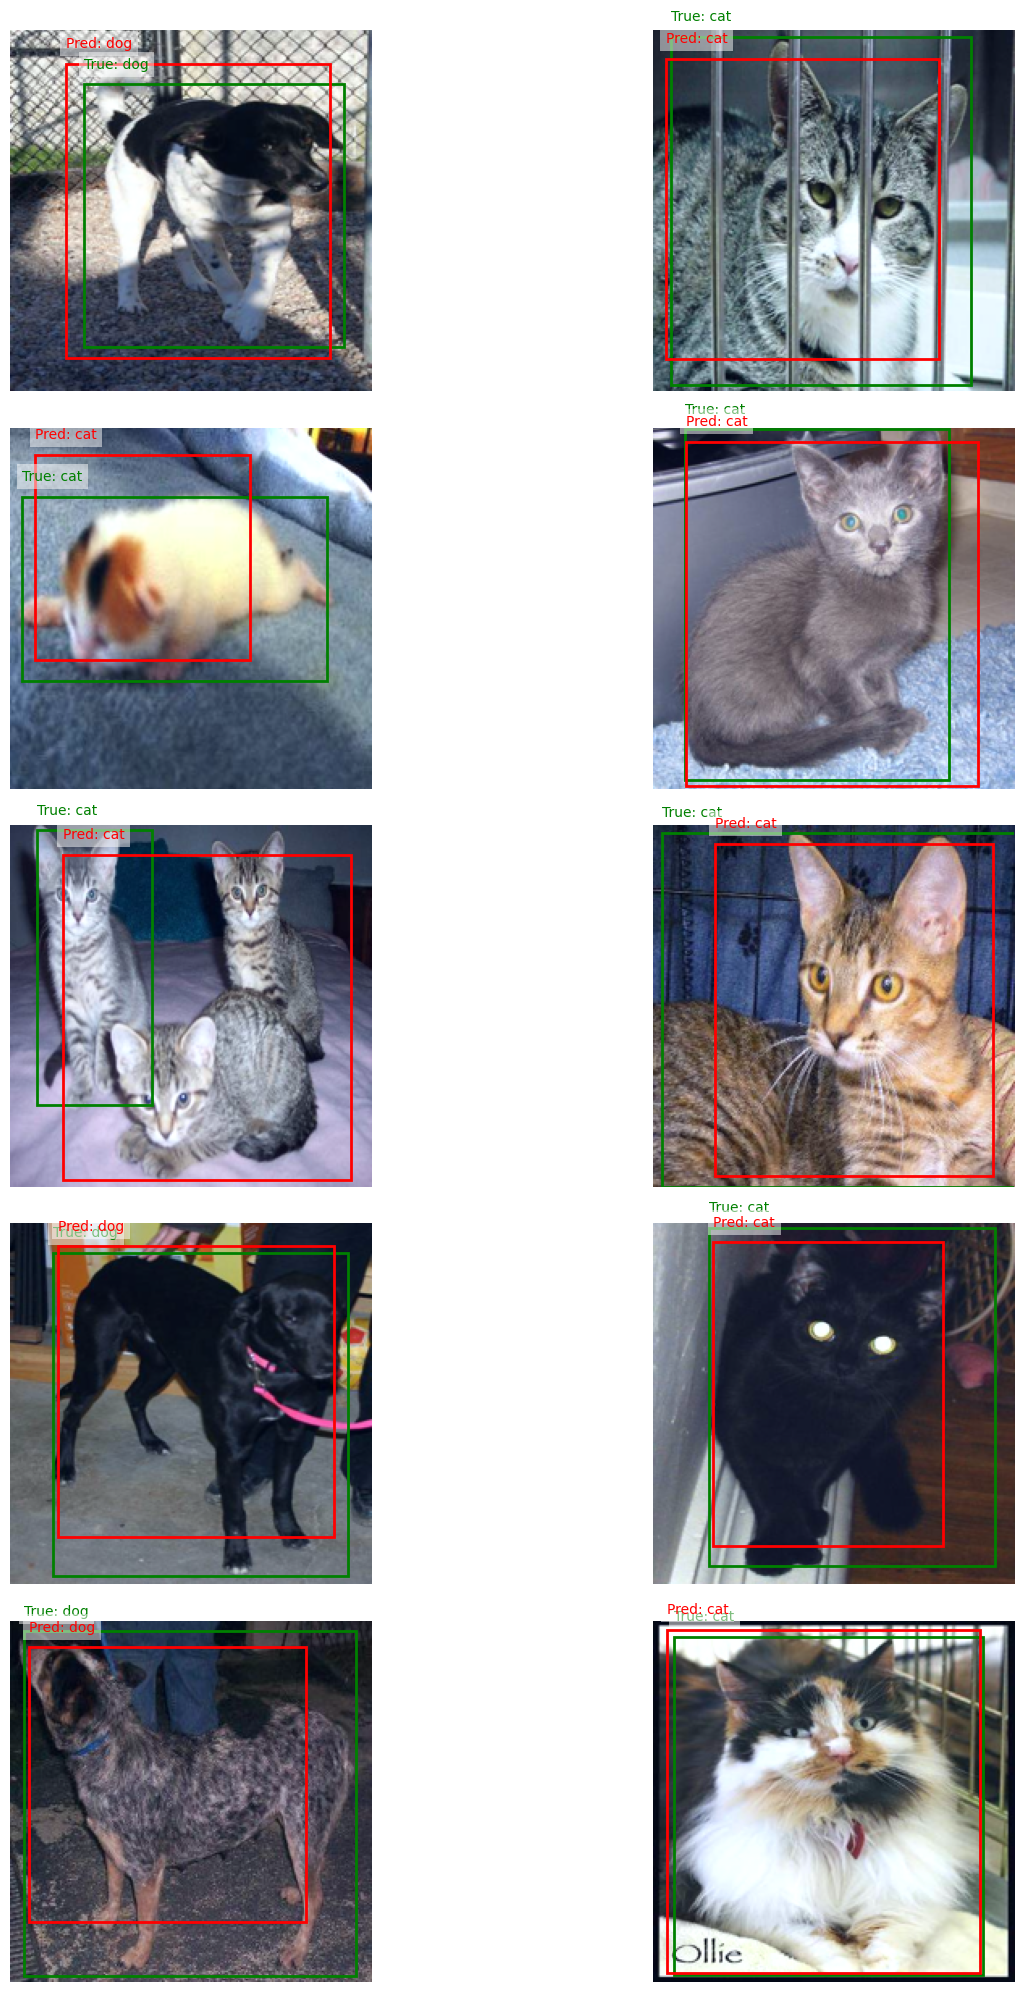

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

# Убедитесь, что модель в режиме оценки
model.eval()

# Количество примеров для отображения
num_examples = 10  # 5 строк * 2 столбца

# Словарь для преобразования меток в строки
class_map = {0: 'cat', 1: 'dog'}

# Итерация по тестовому загрузчику
with torch.no_grad():
    images_shown = 0  # Счетчик отображенных изображений
    fig, axes = plt.subplots(5, 2, figsize=(16, 20))  # Сетка 5x2
    axes = axes.flatten()  # Упрощаем доступ к каждому графику

    for images, bboxes, labels in test_dataloader:
        # Перемещаем данные на устройство
        images = images.to(device)
        bboxes = bboxes.to(device)

        # Получаем предсказания
        predicted_bboxes, predicted_labels = model(images)

        # Переходим обратно на CPU для визуализации
        images = images.cpu()
        bboxes = bboxes.cpu()
        labels = labels.cpu()
        predicted_bboxes = predicted_bboxes.cpu()
        predicted_labels = predicted_labels.cpu()

        for i in range(images.size(0)):
            if images_shown >= num_examples:
                break

            # Текущий график
            ax = axes[images_shown]

            # Извлекаем изображение, true bbox, true label, pred bbox, pred label
            image = images[i].permute(1, 2, 0).numpy()  # Меняем порядок размерностей для plt
            true_bbox = bboxes[i].numpy()
            true_label = labels[i].item()
            pred_bbox = predicted_bboxes[i].numpy()
            pred_label_idx = torch.argmax(predicted_labels[i]).item()
            pred_label = class_map[pred_label_idx]
            true_label_str = class_map[true_label]

            # Денормализация изображения (если применялась нормализация)
            image = (image * 0.229 + 0.485).clip(0, 1)  # mean и std должны быть как в обучении

            # Визуализация
            ax.imshow(image)

            # Рисуем true bounding box
            rect_true = patches.Rectangle(
                (true_bbox[0], true_bbox[1]),  # xmin, ymin
                true_bbox[2] - true_bbox[0],  # width
                true_bbox[3] - true_bbox[1],  # height
                linewidth=2,
                edgecolor='green',
                facecolor='none'
            )
            ax.add_patch(rect_true)

            # Рисуем предсказанный bounding box
            rect_pred = patches.Rectangle(
                (pred_bbox[0], pred_bbox[1]),  # xmin, ymin
                pred_bbox[2] - pred_bbox[0],  # width
                pred_bbox[3] - pred_bbox[1],  # height
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect_pred)

            # Добавляем текст для true и pred bbox
            ax.text(
                true_bbox[0], true_bbox[1] - 10,
                f"True: {true_label_str}",
                color='green',
                fontsize=10,
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
            )
            ax.text(
                pred_bbox[0], pred_bbox[1] - 10,
                f"Pred: {pred_label}",
                color='red',
                fontsize=10,
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
            )

            # Убираем оси для чистоты
            ax.axis('off')

            images_shown += 1

        if images_shown >= num_examples:
            break

    plt.tight_layout()
    plt.show()

<p class="task" id="6"></p>

7\. Найдите в сети несколько изображений котов и собак. Используя любой инструмент для разметки (например, [CVAT](https://www.cvat.ai/)), выделите котов и собак на изображениях. Вставьте скриншот экспортированного файла с разметкой. Используя полученные изображения, визуализируйте разметку и bounding boxes, полученные при помощи модели.

In [ ]:
import zipfile

zip_file_path = '/content/labels_dl 2.zip'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
# Путь к файлу cat.0.xml (предполагаем, что он в распакованной директории)
xml_file_path = '/content/labels_dl 2/cat2.xml'  # Обновите путь, если файл находится в подпапках

# Применяем функцию parse_xml к файлу cat.0.xml
result = parse_xml(xml_file_path)

# Выводим результат
print(result)

{'raw': {'xmin': 109, 'ymin': 220, 'xmax': 798, 'ymax': 718}, 'scaled': {'xmin': 0.10770750988142293, 'ymin': 0.2887139107611549, 'xmax': 0.7885375494071146, 'ymax': 0.9422572178477691}, 'obj_name': 'cat '}


In [ ]:
class AnimalDetectionDataset(Dataset):
    def __init__(self, root_dir, transform=None, label_transform=None, return_scaled=False):
        """
        Класс датасета для задачи детекции объектов.

        Args:
            root_dir (str): Корневая директория с данными.
            transform (callable, optional): Преобразования для изображений.
            label_transform (callable, optional): Преобразование меток объектов.
            return_scaled (bool): Возвращать ли нормированные координаты.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.label_transform = label_transform
        self.return_scaled = return_scaled

        # Список всех изображений и XML-аннотаций
        self.image_files = sorted(
            [f for f in os.listdir(root_dir) if f.endswith(".png")]
        )
        self.annotation_files = sorted(
            [f for f in os.listdir(root_dir) if f.endswith(".xml")]
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Чтение изображения
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")

        # Чтение аннотации
        xml_path = os.path.join(self.root_dir, self.annotation_files[idx])
        annotation = parse_xml(xml_path)

        # Выбор координат
        bbox = annotation["scaled"] if self.return_scaled else annotation["raw"]
        label = annotation["obj_name"]

        # Применение преобразований
        if self.transform:
            image = self.transform(image)
        if self.label_transform:
            label = self.label_transform(label)

        return image, bbox, label


In [ ]:
# Преобразование меток (в данном случае просто преобразование в индекс)
def label_transform(label):
    label_map = {"cat ": 0, "dog": 1}  # Пример словаря меток
    return label_map[label]

In [ ]:
import torchvision.transforms as T

# Преобразования для изображений
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

root_dir = "/content/labels_dl 2"

# Создание экземпляра датасета
dataset = AnimalDetectionDataset(
    root_dir=root_dir,
    transform=transform,
    label_transform=label_transform,
    return_scaled=False
)

len(dataset)

15

In [ ]:
# Создание DataLoader
data_loader = DataLoader(dataset, batch_size=4, shuffle=True)

# Пример итерации по данным
for images, bboxes, labels in data_loader:
    print("Batch of images shape:", images.shape)
    print("Bounding boxes:", bboxes)
    print("Labels:", labels)
    break

Batch of images shape: torch.Size([4, 3, 224, 224])
Bounding boxes: {'xmin': tensor([ 89, 147,  75, 143]), 'ymin': tensor([ 17, 102,  44, 151]), 'xmax': tensor([698, 663, 781, 843]), 'ymax': tensor([652, 673, 851, 708])}
Labels: tensor([0, 0, 0, 1])


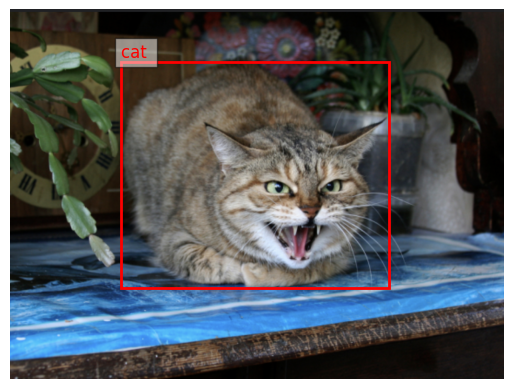

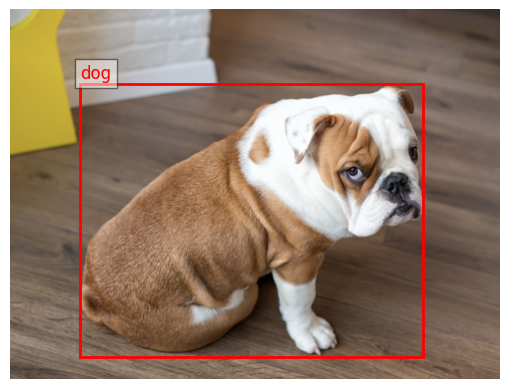

In [ ]:
dataset = AnimalDetectionDataset(
    root_dir="/content/labels_dl 2",  # Замените на путь к вашим данным
    transform=None,
    label_transform=None,
    return_scaled=False
)

# Визуализация изображения кошки
cat_image, cat_bbox, cat_label = dataset[4]  # Предполагаем, что 0 — индекс изображения кошки
show_image_with_bounding_box(cat_image, cat_bbox, cat_label)

# Визуализация изображения собаки
dog_image, dog_bbox, dog_label = dataset[-2]  # Предполагаем, что 1 — индекс изображения собаки
show_image_with_bounding_box(dog_image, dog_bbox, dog_label)

In [ ]:
image_files = sorted([f for f in os.listdir(root_dir) if f.endswith(".png")])
annotation_files = sorted([f for f in os.listdir(root_dir) if f.endswith(".xml")])

print("Найденные изображения:", image_files)
print("Найденные аннотации:", annotation_files)

Найденные изображения: ['cat1.png', 'cat2.png', 'cat3.png', 'cat4.png', 'cat5.png', 'cat6.png', 'cat7.png', 'dog1.png', 'dog2.png', 'dog3.png', 'dog4.png', 'dog5.png', 'dog6.png', 'dog7.png', 'dog8.png']
Найденные аннотации: ['cat1.xml', 'cat2.xml', 'cat3.xml', 'cat4.xml', 'cat5.xml', 'cat6.xml', 'cat7.xml', 'dog1.xml', 'dog2.xml', 'dog3.xml', 'dog4.xml', 'dog5.xml', 'dog6.xml', 'dog7.xml', 'dog8.xml']


<p class="task" id="7"></p>

8\. Повторите решение предыдущей задачи, используя модель `fasterrcnn_resnet50_fpn`. Замените слой для предсказания bounding box на `FastRCNNPredictor` с нужным количеством классов.

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 141MB/s]


Epoch 1/20, Total Loss: 2.8521, Components: {'loss_classifier': tensor(0.0648, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1193, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0058, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0098, device='cuda:0', grad_fn=<DivBackward0>)}
Epoch 2/20, Total Loss: 1.4981, Components: {'loss_classifier': tensor(0.0661, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1433, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0007, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0051, device='cuda:0', grad_fn=<DivBackward0>)}
Epoch 3/20, Total Loss: 1.5026, Components: {'loss_classifier': tensor(0.0912, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1404, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0004, de

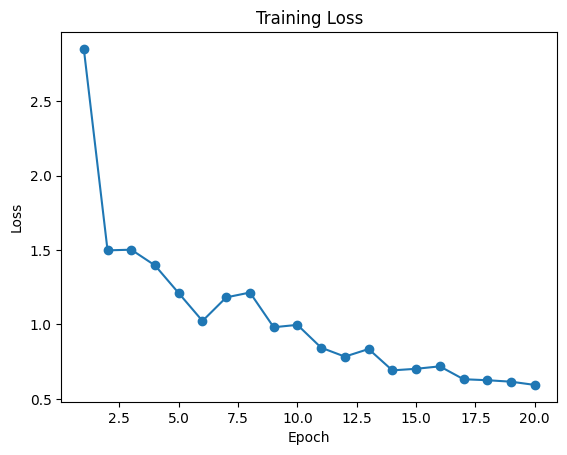

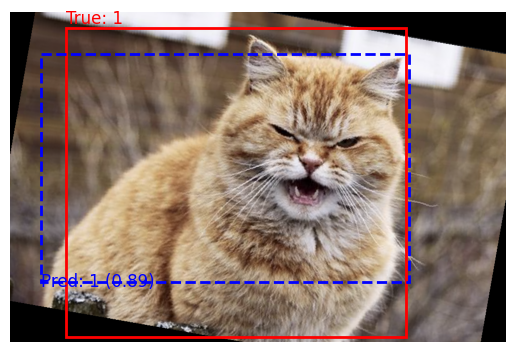

In [ ]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from PIL import Image
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import xml.etree.ElementTree as ET
from torchvision.transforms.functional import hflip, rotate

# Парсинг XML-аннотации
def parse_xml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()
    bboxes = []
    labels = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Проверка валидности bounding box
        if xmax > xmin and ymax > ymin:
            bboxes.append([xmin, ymin, xmax, ymax])
            labels.append(name)
    return {"bboxes": bboxes, "labels": labels}

# Класс датасета для Faster R-CNN
class AnimalDetectionDataset(Dataset):
    def __init__(self, root_dir, transform=None, augment=False):
        self.root_dir = root_dir
        self.image_files = sorted([f for f in os.listdir(root_dir) if f.endswith(".png")])
        self.annotation_files = sorted([f for f in os.listdir(root_dir) if f.endswith(".xml")])
        self.transform = transform
        self.augment = augment
        self.label_map = {"cat": 1, "dog": 2}  # 1: кошка, 2: собака

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        xml_path = os.path.join(self.root_dir, self.annotation_files[idx])

        image = Image.open(img_path).convert("RGB")
        annotation = parse_xml(xml_path)
        bboxes = torch.tensor(annotation["bboxes"], dtype=torch.float32)
        labels = torch.tensor([self.label_map[label] for label in annotation["labels"]], dtype=torch.int64)

        if self.augment:
            # Применяем простые аугментации
            if torch.rand(1).item() > 0.5:
                image = hflip(image)
                bboxes[:, [0, 2]] = image.width - bboxes[:, [2, 0]]  # Корректировка боксов
            if torch.rand(1).item() > 0.5:
                angle = torch.randint(-30, 30, (1,)).item()
                image = rotate(image, angle)

        if self.transform:
            image = self.transform(image)

        target = {"boxes": bboxes, "labels": labels}
        return image, target

# Преобразования для изображений
transform = T.Compose([
    T.ToTensor(),
])

# Путь к данным
root_dir = "/content/labels_dl 2"
dataset = AnimalDetectionDataset(root_dir=root_dir, transform=transform, augment=True)
data_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Инициализация модели Faster R-CNN
num_classes = 3  # Кошка, собака и фон
model = fasterrcnn_resnet50_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Оптимизатор
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Обучение модели
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epoch_losses = []
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    epoch_losses.append(epoch_loss)
    print(f"Epoch {epoch + 1}/{num_epochs}, Total Loss: {epoch_loss:.4f}, Components: {loss_dict}")

# График функции потерь
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# Визуализация предсказаний
def visualize_predictions(model, dataset, idx):
    model.eval()
    image, target = dataset[idx]
    with torch.no_grad():
        prediction = model([image.to(device)])[0]

    image = image.permute(1, 2, 0).cpu().numpy()
    plt.imshow(image)
    ax = plt.gca()

    for bbox, label in zip(target["boxes"], target["labels"]):
        xmin, ymin, xmax, ymax = bbox.tolist()
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                 linewidth=2, edgecolor="r", facecolor="none")
        ax.add_patch(rect)
        ax.text(xmin, ymin - 10, f"True: {label.item()}", color="red", fontsize=12)

    for bbox, label, score in zip(prediction["boxes"], prediction["labels"], prediction["scores"]):
        if score > 0.5:
            xmin, ymin, xmax, ymax = bbox.tolist()
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=2, edgecolor="blue", facecolor="none", linestyle="--")
            ax.add_patch(rect)
            ax.text(xmin, ymax + 10, f"Pred: {label.item()} ({score:.2f})", color="blue", fontsize=12)

    plt.axis("off")
    plt.show()

# Пример визуализации
visualize_predictions(model, dataset, idx=0)